# Hierarchical WordNet CBM — species → genus → family

**P1 Project — Politecnico di Torino, 2025/2026**  
Luca Prato, Niccolò Sipala, Elziario Paduano

Extends the Concept Bottleneck Model with a **class-level hierarchy** derived from WordNet:
- Backbone: ResNet-50 fine-tuned end-to-end (same as baseline)
- Taxonomy: WordNet synsets → species → genus → family (3 levels)
- Local concept heads: one per internal taxonomy node, using discriminative CUB attributes
- Training: teacher-forced; inference: greedy top-down


## Architecture

```
Image
  → ResNet-50 backbone (2048-d features, fine-tuned)
  → Root head:   Linear(2048, K_root)   → Sigmoid → Linear(K_root, N_families)
  → [greedy: pick top family f]
  → Family head_f: Linear(2048, K_fam)  → Sigmoid → Linear(K_fam,  N_genera_in_f)
  → [greedy: pick top genus g]
  → Genus head_g:  Linear(2048, K_gen)  → Sigmoid → Linear(K_gen,   N_species_in_g)
  → predicted species
```

Loss (teacher-forced training):
```
L = λ_fam·CE(family) + λ_gen·CE(genus) + λ_sp·CE(species)
  + λ_c · [BCE(root_concepts) + BCE(family_concepts) + BCE(genus_concepts)] / 3
```


In [1]:
!pip install torch torchvision matplotlib seaborn pandas numpy Pillow tqdm nltk --quiet
print('Dependencies ready.')

Dependencies ready.


In [2]:
import random, os, json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import wordnet as wn

SEED = 42
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    os.environ['PYTHONHASHSEED'] = str(seed)
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


In [3]:
DATA_DIR = '/content/data'
CUB_DIR  = os.path.join(DATA_DIR, 'CUB_200_2011')
SAVE_DIR = '/content/processed'
os.makedirs(SAVE_DIR, exist_ok=True)

CERTAINTY_THRESHOLD = 3
BATCH_SIZE     = 64
NUM_WORKERS    = 2
N_CONCEPTS     = 312
N_CLASSES      = 200
N_EPOCHS       = 40
BACKBONE_DIM   = 2048

# Concept budget per local head
K_ROOT   = 80
K_FAMILY = 50
K_GENUS  = 30

# Loss weights
LAMBDA_FAMILY  = 0.5
LAMBDA_GENUS   = 1.0
LAMBDA_SPECIES = 2.0
LAMBDA_CONCEPT = 0.5

CKPT_PATH = os.path.join(SAVE_DIR, 'wordnet_cbm_best.pt')
print('Config ready.')


Config ready.


In [5]:
import os, urllib.request, tarfile

DATA_DIR = '/content/data'
CUB_DIR  = os.path.join(DATA_DIR, 'CUB_200_2011')
CUB_URL  = 'https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz'
CUB_TGZ  = os.path.join(DATA_DIR, 'CUB_200_2011.tgz')
SAVE_DIR = '/content/processed'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

if not os.path.exists(CUB_DIR):
    print('Downloading CUB-200-2011 (~1.1 GB)...')
    req = urllib.request.Request(CUB_URL, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response:
        with open(CUB_TGZ, 'wb') as out_file:
            out_file.write(response.read())
    print('Extracting...')
    with tarfile.open(CUB_TGZ, 'r:gz') as tar:
        tar.extractall(DATA_DIR)
    print('Done.')
else:
    print('CUB already present.')

print('\nCUB root contents:')
for f in sorted(os.listdir(CUB_DIR)):
    print(' ', f)

Extracting...


/tmp/ipykernel_1638/3622098181.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Done.

CUB root contents:
  README
  attributes
  bounding_boxes.txt
  classes.txt
  image_class_labels.txt
  images
  images.txt
  parts
  train_test_split.txt


In [6]:
# move /content/data/attributes.txt in /content/data/CUB_200_2011/attributes
!mv /content/data/attributes.txt /content/data/CUB_200_2011/attributes

In [7]:
def load_txt(filename, col_names, sep=' '):
    return pd.read_csv(os.path.join(CUB_DIR, filename),
                       sep=sep, header=None, names=col_names)

images_df  = load_txt('images.txt',             ['img_id', 'filepath'])
labels_df  = load_txt('image_class_labels.txt', ['img_id', 'class_id'])
split_df   = load_txt('train_test_split.txt',   ['img_id', 'is_train'])
classes_df = load_txt('classes.txt',            ['class_id', 'class_name'])
attrs_df   = load_txt('attributes/attributes.txt', ['attr_id', 'attr_name'])

img_attr_data = np.loadtxt(
    os.path.join(CUB_DIR, 'attributes/image_attribute_labels.txt'),
    dtype=int, usecols=range(5)
)
img_attr_df = pd.DataFrame(img_attr_data,
    columns=['img_id', 'attr_id', 'is_present', 'certainty', 'time'])

master_df = (images_df
    .merge(labels_df,  on='img_id')
    .merge(split_df,   on='img_id')
    .merge(classes_df, on='class_id'))

img_attr_filt = img_attr_df[img_attr_df['certainty'] >= CERTAINTY_THRESHOLD].copy()
concept_matrix = img_attr_filt.pivot_table(
    index='img_id', columns='attr_id', values='is_present', fill_value=0
).astype(np.float32)
all_attr_ids = sorted(attrs_df['attr_id'].tolist())
concept_matrix = concept_matrix.reindex(columns=all_attr_ids, fill_value=0)

attrs_df[['part','descriptor']] = attrs_df['attr_name'].str.split('::', expand=True)
print(f'Images: {len(master_df)}  Train: {master_df.is_train.sum()}  '
      f'Test: {(~master_df.is_train.astype(bool)).sum()}  Concepts: {N_CONCEPTS}')


/tmp/ipykernel_1638/2824620164.py:11: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  img_attr_data = np.loadtxt(


Images: 11788  Train: 5994  Test: 5794  Concepts: 312


In [8]:
def get_bird_synset(class_name):
    """Find WordNet synset for a CUB class name like '001.Black_footed_Albatross'."""
    raw = class_name.split('.', 1)[-1].lower().replace('_', ' ')
    candidates = [raw, ' '.join(raw.split()[-2:]), raw.split()[-1]]
    for query in candidates:
        synsets = wn.synsets(query.replace(' ', '_'), pos=wn.NOUN)
        for s in synsets:
            ancestors = set(h.name() for h in s.closure(lambda x: x.hypernyms()))
            if any('bird' in h or 'fowl' in h for h in ancestors):
                return s
    return None

# Synset names that are too general to use as a family label
_TOO_GENERAL = {
    'bird.n.01', 'fowl.n.01', 'fowl.n.02',
    'vertebrate.n.01', 'chordate.n.01', 'animal.n.01', 'organism.n.01',
    'living_thing.n.01', 'whole.n.02', 'object.n.01',
    'physical_entity.n.01', 'entity.n.01',
}

def get_genus_family(synset):
    """
    Genus  = the synset itself (the common bird group, e.g. 'albatross', 'warbler').
    Family = the direct hypernym of that synset in WordNet
             (e.g. 'seabird' for albatross, 'passerine' for warblers).
    If the hypernym is too general (bird.n.01 or above), family falls back to genus.
    """
    if synset is None:
        return None, None
    genus = synset.lemmas()[0].name().replace('_', ' ')
    hypernyms = synset.hypernyms()
    if not hypernyms:
        return genus, genus
    parent = hypernyms[0]
    if parent.name() in _TOO_GENERAL:
        return genus, genus   # synset sits directly under bird; no useful family level
    family = parent.lemmas()[0].name().replace('_', ' ')
    return genus, family

print('Mapping 200 CUB species to WordNet taxonomy...')
class_taxonomy = {}  # class_id (1-200) -> {'genus': str, 'family': str}
missing = []
for _, row in classes_df.iterrows():
    cid  = int(row['class_id'])
    name = str(row['class_name'])
    syn  = get_bird_synset(name)
    if syn is None:
        missing.append(name)
        parts  = name.split('.', 1)[-1].lower().replace('_', ' ').split()
        genus  = parts[-1] if parts else 'unknown'
        family = (parts[-2] if len(parts) > 1 else genus) + ' (fallback)'
    else:
        genus, family = get_genus_family(syn)
    class_taxonomy[cid] = {'genus': genus, 'family': family}

print(f'WordNet found : {200 - len(missing)}/200')
print(f'Fallback used : {len(missing)} species')
if missing:
    print(f'  Examples: {missing[:5]}')


Mapping 200 CUB species to WordNet taxonomy...
WordNet found : 193/200
Fallback used : 7 species
  Examples: ['022.Chuck_will_Widow', '044.Frigatebird', '046.Gadwall', '070.Green_Violetear', '105.Whip_poor_Will']


In [9]:
all_genera   = sorted(set(v['genus']  for v in class_taxonomy.values()))
all_families = sorted(set(v['family'] for v in class_taxonomy.values()))
genus_to_id  = {g: i for i, g in enumerate(all_genera)}
family_to_id = {f: i for i, f in enumerate(all_families)}

species_to_genus  = {}   # class_id (1-indexed) -> genus_id  (0-indexed)
species_to_family = {}   # class_id (1-indexed) -> family_id (0-indexed)
genus_to_family_map  = {}  # genus_id  -> family_id
family_to_genera_map = {}  # family_id -> sorted list of genus_ids
genus_to_species_map = {}  # genus_id  -> list of species_ids (0-indexed)

for cid, info in class_taxonomy.items():
    gid = genus_to_id[info['genus']]
    fid = family_to_id[info['family']]
    species_to_genus[cid]  = gid
    species_to_family[cid] = fid
    genus_to_family_map[gid] = fid
    family_to_genera_map.setdefault(fid, set()).add(gid)
    genus_to_species_map.setdefault(gid, []).append(cid - 1)  # 0-indexed species id

family_to_genera_map = {k: sorted(v) for k, v in family_to_genera_map.items()}

N_GENERA   = len(all_genera)
N_FAMILIES = len(all_families)
print(f'Taxonomy: {N_FAMILIES} families  ->  {N_GENERA} genera  ->  200 species')
print()
print(f"{'Family':<35} {'Genera':>6}  {'Species':>7}")
print('-' * 52)
for fid in range(N_FAMILIES):
    fname = all_families[fid]
    gids  = family_to_genera_map[fid]
    n_sp  = sum(len(genus_to_species_map[g]) for g in gids)
    print(f'{fname:<35} {len(gids):>6}  {n_sp:>7}')


Taxonomy: 62 families  ->  109 genera  ->  200 species

Family                              Genera  Species
----------------------------------------------------
New World blackbird                      2        3
New World flycatcher                     1        1
New World jay                            1        1
New World oriole                         4        6
New World sparrow                        4        4
New World warbler                        5        5
New Zealand wren                         1        1
apodiform bird                           1        3
auk                                      1        4
bird genus                               2        2
bunting                                  1        1
coastal diving bird                      1        2
coraciiform bird                         1        4
corvine bird                             3        5
creeper                                  1        1
crow                                     1        1
cuckoo 

In [10]:
# Per-class mean concept vector from training images only
train_class_means = {}
for cid in range(1, 201):
    img_ids_c = master_df[(master_df['is_train'] == 1) &
                           (master_df['class_id'] == cid)]['img_id']
    valid = [i for i in img_ids_c if i in concept_matrix.index]
    train_class_means[cid] = (
        concept_matrix.loc[valid].values.mean(axis=0) if valid
        else np.zeros(N_CONCEPTS)
    )

def top_discriminative(class_ids, n_select):
    """Return indices (0-based, into 312-concept space) of the n_select
    concepts with highest variance of per-class mean vectors."""
    if len(class_ids) < 2:
        return list(range(min(n_select, N_CONCEPTS)))
    means = np.stack([train_class_means[cid] for cid in class_ids])
    variances = means.var(axis=0)
    k = min(n_select, N_CONCEPTS)
    return sorted(np.argsort(variances)[-k:].tolist())

# Root: discriminative across all 200 species
root_concept_mask = top_discriminative(list(range(1, 201)), K_ROOT)

# Per-family: representative species per genus -> discriminative across genera
family_concept_masks = {}
for fid, gids in family_to_genera_map.items():
    rep_cids = [genus_to_species_map[gid][0] + 1 for gid in gids]
    family_concept_masks[fid] = top_discriminative(rep_cids, K_FAMILY)

# Per-genus: discriminative across species within genus
genus_concept_masks = {}
for gid, sp_ids in genus_to_species_map.items():
    genus_concept_masks[gid] = top_discriminative([s + 1 for s in sp_ids], K_GENUS)

print(f'Root concept budget    : {len(root_concept_mask)}')
print(f'Avg family concept     : {np.mean([len(v) for v in family_concept_masks.values()]):.1f}')
print(f'Avg genus concept      : {np.mean([len(v) for v in genus_concept_masks.values()]):.1f}')


Root concept budget    : 80
Avg family concept     : 50.0
Avg genus concept      : 30.0


In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
test_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class CUBTaxonomyDataset(Dataset):
    def __init__(self, df, concept_matrix, cub_dir, s2g, s2f, transform=None):
        self.df = df.copy().reset_index(drop=True)
        self.concept_matrix = concept_matrix
        self.cub_dir = cub_dir
        self.s2g = s2g; self.s2f = s2f
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img_id = row['img_id']
        image  = Image.open(
            os.path.join(self.cub_dir, 'images', row['filepath'])
        ).convert('RGB')
        if self.transform:
            image = self.transform(image)
        concepts = (
            torch.tensor(self.concept_matrix.loc[img_id].values, dtype=torch.float32)
            if img_id in self.concept_matrix.index
            else torch.zeros(N_CONCEPTS, dtype=torch.float32)
        )
        cid_1     = int(row['class_id'])
        species   = cid_1 - 1
        genus_id  = self.s2g[cid_1]
        family_id = self.s2f[cid_1]
        return image, concepts, species, genus_id, family_id

train_df = master_df[master_df['is_train'] == 1]
test_df  = master_df[master_df['is_train'] == 0]

train_ds = CUBTaxonomyDataset(train_df, concept_matrix, CUB_DIR,
                               species_to_genus, species_to_family, train_transform)
test_ds  = CUBTaxonomyDataset(test_df,  concept_matrix, CUB_DIR,
                               species_to_genus, species_to_family, test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print(f'Train: {len(train_loader)} batches   Test: {len(test_loader)} batches')


Train: 94 batches   Test: 91 batches


In [12]:
class LocalConceptHead(nn.Module):
    """2048 -> n_local_concepts (sigmoid) -> n_children logits."""
    def __init__(self, in_dim, n_local_concepts, n_children):
        super().__init__()
        self.concept_net  = nn.Sequential(nn.Linear(in_dim, n_local_concepts), nn.Sigmoid())
        self.child_linear = nn.Linear(n_local_concepts, n_children)

    def forward(self, x):
        c = self.concept_net(x)
        return self.child_linear(c), c   # (logits, concept_scores)


class WordNetCBM(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])  # (B,2048,1,1)

        self.root_head = LocalConceptHead(BACKBONE_DIM, K_ROOT, N_FAMILIES)

        self.family_heads = nn.ModuleDict({
            str(fid): LocalConceptHead(BACKBONE_DIM,
                                       len(family_concept_masks[fid]),
                                       len(gids))
            for fid, gids in family_to_genera_map.items()
        })

        self.genus_heads = nn.ModuleDict({
            str(gid): LocalConceptHead(BACKBONE_DIM,
                                       len(genus_concept_masks[gid]),
                                       len(sp_ids))
            for gid, sp_ids in genus_to_species_map.items()
        })

    def features(self, x):
        return self.backbone(x).flatten(1)  # (B, 2048)

    def forward_train(self, x, true_family, true_genus):
        """Teacher-forced: routes each sample through its ground-truth family/genus head."""
        feats = self.features(x)
        B = feats.shape[0]

        family_logits, root_concepts = self.root_head(feats)

        genus_logits = torch.full((B, N_GENERA), -1e4, device=feats.device)
        fam_concept_preds = {}
        for fid in true_family.unique().tolist():
            fid = int(fid); m = (true_family == fid)
            g_log, fam_c = self.family_heads[str(fid)](feats[m])
            fam_concept_preds[fid] = (m, fam_c)
            for li, gid in enumerate(family_to_genera_map[fid]):
                genus_logits[m, gid] = g_log[:, li]

        species_logits = torch.full((B, N_CLASSES), -1e4, device=feats.device)
        gen_concept_preds = {}
        for gid in true_genus.unique().tolist():
            gid = int(gid); m = (true_genus == gid)
            s_log, gen_c = self.genus_heads[str(gid)](feats[m])
            gen_concept_preds[gid] = (m, gen_c)
            for li, sid in enumerate(genus_to_species_map[gid]):
                species_logits[m, sid] = s_log[:, li]

        return (family_logits, genus_logits, species_logits,
                root_concepts, fam_concept_preds, gen_concept_preds)

    @torch.no_grad()
    def forward_greedy(self, x):
        """Top-down greedy inference without teacher forcing."""
        feats = self.features(x)
        B = feats.shape[0]

        family_logits, _ = self.root_head(feats)
        pred_fam = family_logits.argmax(dim=1)

        genus_logits = torch.full((B, N_GENERA), -1e4, device=feats.device)
        for fid in pred_fam.unique().tolist():
            fid = int(fid); m = (pred_fam == fid)
            g_log, _ = self.family_heads[str(fid)](feats[m])
            for li, gid in enumerate(family_to_genera_map[fid]):
                genus_logits[m, gid] = g_log[:, li]
        pred_gen = genus_logits.argmax(dim=1)

        species_logits = torch.full((B, N_CLASSES), -1e4, device=feats.device)
        for gid in pred_gen.unique().tolist():
            gid = int(gid); m = (pred_gen == gid)
            s_log, _ = self.genus_heads[str(gid)](feats[m])
            for li, sid in enumerate(genus_to_species_map[gid]):
                species_logits[m, sid] = s_log[:, li]
        pred_sp = species_logits.argmax(dim=1)

        return pred_fam, pred_gen, pred_sp

model = WordNetCBM().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'WordNetCBM  params={n_params:,}')
print(f'  N_FAMILIES={N_FAMILIES}  N_GENERA={N_GENERA}  N_CLASSES={N_CLASSES}')


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


WordNetCBM  params=36,740,914
  N_FAMILIES=62  N_GENERA=109  N_CLASSES=200


In [13]:
bce_fn = nn.BCELoss()
ce_fn  = nn.CrossEntropyLoss()

def compute_loss(family_logits, genus_logits, species_logits,
                 root_concepts, fam_cp, gen_cp,
                 true_fam, true_gen, true_sp, full_concepts):
    l_fam = ce_fn(family_logits, true_fam)
    l_gen = ce_fn(genus_logits,  true_gen)
    l_sp  = ce_fn(species_logits, true_sp)

    # Concept losses: each head supervised on its local concept subset
    l_c_root = bce_fn(root_concepts, full_concepts[:, root_concept_mask])

    l_c_fam = torch.tensor(0., device=family_logits.device)
    for fid, (m, fam_c) in fam_cp.items():
        l_c_fam = l_c_fam + bce_fn(fam_c, full_concepts[m][:, family_concept_masks[fid]])
    if fam_cp:
        l_c_fam = l_c_fam / len(fam_cp)

    l_c_gen = torch.tensor(0., device=family_logits.device)
    for gid, (m, gen_c) in gen_cp.items():
        l_c_gen = l_c_gen + bce_fn(gen_c, full_concepts[m][:, genus_concept_masks[gid]])
    if gen_cp:
        l_c_gen = l_c_gen / len(gen_cp)

    l_concept = (l_c_root + l_c_fam + l_c_gen) / 3
    total = (LAMBDA_FAMILY * l_fam + LAMBDA_GENUS * l_gen +
             LAMBDA_SPECIES * l_sp + LAMBDA_CONCEPT * l_concept)
    return total, {'family': l_fam.item(), 'genus': l_gen.item(),
                   'species': l_sp.item(), 'concept': l_concept.item()}


def train_epoch(model, loader, optimizer):
    model.train()
    tot = tot_sp_correct = n_total = 0
    for imgs, concepts, sp, gen, fam in tqdm(loader, desc='  train', leave=False):
        imgs = imgs.to(device); concepts = concepts.to(device)
        sp = sp.to(device); gen = gen.to(device); fam = fam.to(device)
        optimizer.zero_grad()
        fam_log, gen_log, sp_log, root_c, fam_cp, gen_cp = \
            model.forward_train(imgs, fam, gen)
        loss, _ = compute_loss(fam_log, gen_log, sp_log,
                               root_c, fam_cp, gen_cp,
                               fam, gen, sp, concepts)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        n = imgs.size(0)
        tot += loss.item() * n
        tot_sp_correct += (sp_log.argmax(1) == sp).sum().item()
        n_total += n
    nd = len(loader.dataset)
    return {'loss': tot / nd, 'species_acc': tot_sp_correct / n_total}


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    c_sp = c_gen = c_fam = total = 0
    all_pred_sp=[]; all_true_sp=[]
    all_pred_gen=[]; all_true_gen=[]
    all_pred_fam=[]; all_true_fam=[]
    for imgs, concepts, sp, gen, fam in tqdm(loader, desc='  eval ', leave=False):
        imgs = imgs.to(device)
        pred_fam, pred_gen, pred_sp = model.forward_greedy(imgs)
        c_sp  += (pred_sp  == sp.to(device)).sum().item()
        c_gen += (pred_gen == gen.to(device)).sum().item()
        c_fam += (pred_fam == fam.to(device)).sum().item()
        total += imgs.size(0)
        all_pred_sp.extend(pred_sp.cpu().tolist())
        all_true_sp.extend(sp.tolist())
        all_pred_gen.extend(pred_gen.cpu().tolist())
        all_true_gen.extend(gen.tolist())
        all_pred_fam.extend(pred_fam.cpu().tolist())
        all_true_fam.extend(fam.tolist())
    return {
        'species_acc': c_sp / total,
        'genus_acc':   c_gen / total,
        'family_acc':  c_fam / total,
        'pred_sp': all_pred_sp, 'true_sp': all_true_sp,
        'pred_gen': all_pred_gen, 'true_gen': all_true_gen,
        'pred_fam': all_pred_fam, 'true_fam': all_true_fam,
    }

print('Helpers ready: compute_loss(), train_epoch(), evaluate()')


Helpers ready: compute_loss(), train_epoch(), evaluate()


In [14]:
optimizer = optim.Adam([
    {'params': model.backbone.parameters(),      'lr': 1e-4},
    {'params': list(model.root_head.parameters()) +
               list(model.family_heads.parameters()) +
               list(model.genus_heads.parameters()), 'lr': 1e-3},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3)

history = []
best_sp    = 0.0
best_epoch = 0

for epoch in range(1, N_EPOCHS + 1):
    train_m = train_epoch(model, train_loader, optimizer)
    test_m  = evaluate(model, test_loader)
    scheduler.step(test_m['species_acc'])

    if test_m['species_acc'] > best_sp:
        best_sp, best_epoch = test_m['species_acc'], epoch
        torch.save(model.state_dict(), CKPT_PATH)

    history.append({
        'epoch': epoch,
        'train_loss':    train_m['loss'],
        'train_sp_acc':  train_m['species_acc'],
        'test_sp_acc':   test_m['species_acc'],
        'test_gen_acc':  test_m['genus_acc'],
        'test_fam_acc':  test_m['family_acc'],
    })
    print(
        f'[{epoch:02d}/{N_EPOCHS}] '
        f'loss={train_m["loss"]:.3f}  '
        f'train_sp={train_m["species_acc"]:.3f}  |  '
        f'sp={test_m["species_acc"]:.3f} '
        f'gen={test_m["genus_acc"]:.3f} '
        f'fam={test_m["family_acc"]:.3f} '
        f'[best={best_sp:.3f} @ep{best_epoch}]'
    )

with open(os.path.join(SAVE_DIR, 'wordnet_cbm_history.json'), 'w') as f:
    json.dump(history, f, indent=2)
print(f'Done. Best species acc: {best_sp:.4f} @ epoch {best_epoch}')


[01/40] loss=4.750  train_sp=0.600  |  sp=0.087 gen=0.288 fam=0.401 [best=0.087 @ep1]


[02/40] loss=3.814  train_sp=0.731  |  sp=0.260 gen=0.431 fam=0.502 [best=0.260 @ep2]


[03/40] loss=3.354  train_sp=0.800  |  sp=0.363 gen=0.496 fam=0.556 [best=0.363 @ep3]


[04/40] loss=3.032  train_sp=0.841  |  sp=0.442 gen=0.556 fam=0.601 [best=0.442 @ep4]


[05/40] loss=2.757  train_sp=0.862  |  sp=0.492 gen=0.594 fam=0.643 [best=0.492 @ep5]


...

[36/40] loss=0.904  train_sp=0.970  |  sp=0.775 gen=0.844 fam=0.871 [best=0.775 @ep36]


[37/40] loss=0.860  train_sp=0.973  |  sp=0.776 gen=0.843 fam=0.871 [best=0.776 @ep37]


[38/40] loss=0.865  train_sp=0.973  |  sp=0.774 gen=0.838 fam=0.866 [best=0.776 @ep37]


[39/40] loss=0.873  train_sp=0.972  |  sp=0.774 gen=0.841 fam=0.871 [best=0.776 @ep37]


[40/40] loss=0.826  train_sp=0.976  |  sp=0.781 gen=0.846 fam=0.874 [best=0.781 @ep40]
Done. Best species acc: 0.7813 @ epoch 40


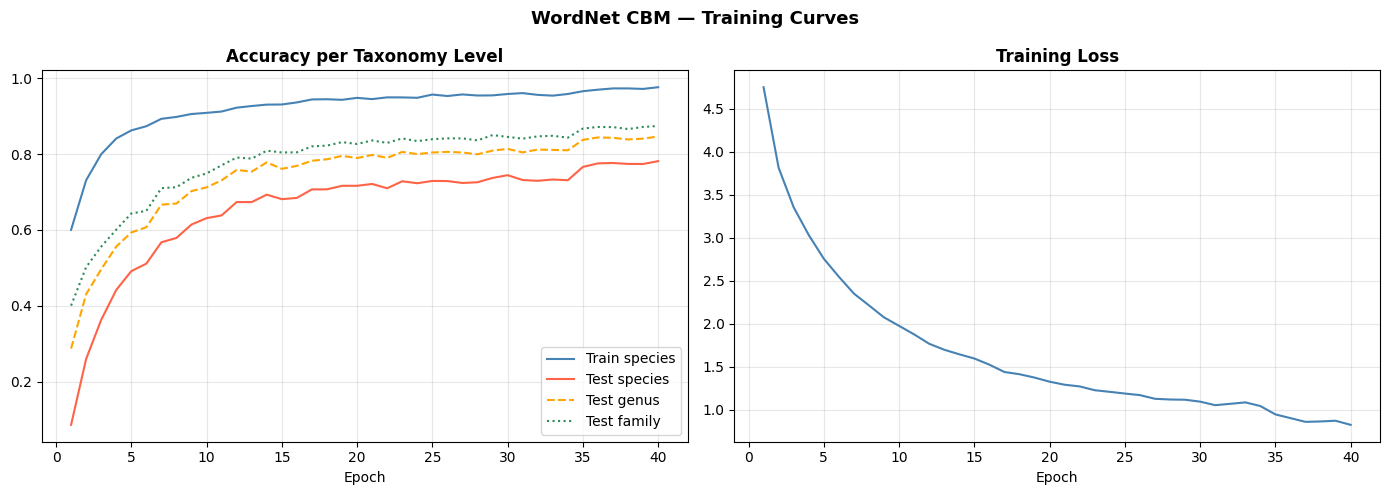

In [15]:
epochs  = [r['epoch']       for r in history]
tr_sp   = [r['train_sp_acc'] for r in history]
te_sp   = [r['test_sp_acc']  for r in history]
te_gen  = [r['test_gen_acc'] for r in history]
te_fam  = [r['test_fam_acc'] for r in history]
tr_loss = [r['train_loss']   for r in history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, tr_sp,  label='Train species', color='steelblue')
axes[0].plot(epochs, te_sp,  label='Test species',  color='tomato')
axes[0].plot(epochs, te_gen, label='Test genus',    color='orange',   linestyle='--')
axes[0].plot(epochs, te_fam, label='Test family',   color='seagreen', linestyle=':')
axes[0].set_title('Accuracy per Taxonomy Level', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, tr_loss, color='steelblue')
axes[1].set_title('Training Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].grid(alpha=0.3)
plt.suptitle('WordNet CBM — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wordnet_cbm_curves.png'), dpi=150)
plt.show()


In [16]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=device, weights_only=True))
final = evaluate(model, test_loader)

print('=' * 55)
print('WORDNET CBM — Final Test Results (greedy inference)')
print('=' * 55)
print(f'  Species Top-1 accuracy : {final["species_acc"]:.4f}  ({final["species_acc"]*100:.2f}%)')
print(f'  Genus   accuracy       : {final["genus_acc"]:.4f}  ({final["genus_acc"]*100:.2f}%)')
print(f'  Family  accuracy       : {final["family_acc"]:.4f}  ({final["family_acc"]*100:.2f}%)')


WORDNET CBM — Final Test Results (greedy inference)
  Species Top-1 accuracy : 0.7813  (78.13%)
  Genus   accuracy       : 0.8464  (84.64%)
  Family  accuracy       : 0.8740  (87.40%)


Mistake Severity (WordNet tree distance)
  Mean tree distance      : 0.994
  Correct       (dist=0)  : 4527 (78.1%)
  Same genus    (dist=2)  :  377 (6.5%)
  Same family   (dist=4)  :  166 (2.9%)
  Diff family   (dist=6)  :  724 (12.5%)

Among wrong predictions:
  Same-genus  mistake rate : 29.8%
  Same-family mistake rate : 42.5%


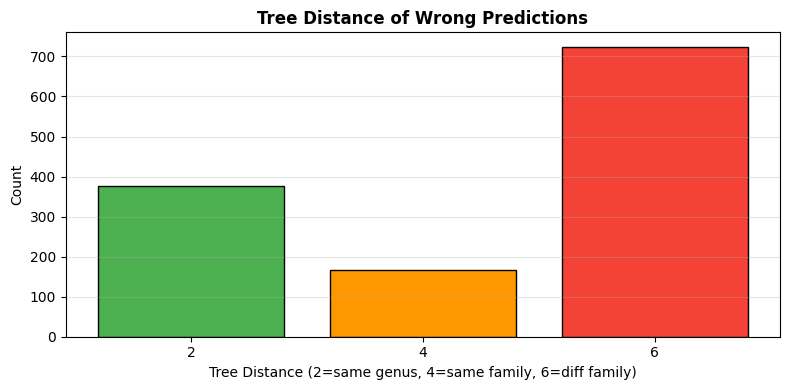

In [17]:
def tree_distance(pred_sp, true_sp):
    """Tree distance: 0 (same), 2 (same genus), 4 (same family), 6 (root)."""
    if pred_sp == true_sp:
        return 0
    if species_to_genus.get(pred_sp+1) == species_to_genus.get(true_sp+1):
        return 2
    if species_to_family.get(pred_sp+1) == species_to_family.get(true_sp+1):
        return 4
    return 6

distances = np.array([tree_distance(p, t)
                      for p, t in zip(final['pred_sp'], final['true_sp'])])

wrong = np.array(final['pred_sp']) != np.array(final['true_sp'])
same_genus_rate  = (np.array(final['pred_gen'])[wrong] ==
                    np.array(final['true_gen'])[wrong]).mean()
same_family_rate = (np.array(final['pred_fam'])[wrong] ==
                    np.array(final['true_fam'])[wrong]).mean()

print('Mistake Severity (WordNet tree distance)')
print(f'  Mean tree distance      : {distances.mean():.3f}')
print(f'  Correct       (dist=0)  : {(distances==0).sum():4d} ({(distances==0).mean():.1%})')
print(f'  Same genus    (dist=2)  : {(distances==2).sum():4d} ({(distances==2).mean():.1%})')
print(f'  Same family   (dist=4)  : {(distances==4).sum():4d} ({(distances==4).mean():.1%})')
print(f'  Diff family   (dist=6)  : {(distances==6).sum():4d} ({(distances==6).mean():.1%})')
print()
print('Among wrong predictions:')
print(f'  Same-genus  mistake rate : {same_genus_rate:.1%}')
print(f'  Same-family mistake rate : {same_family_rate:.1%}')

fig, ax = plt.subplots(figsize=(8, 4))
wrong_dist = distances[distances > 0]
vals, cnts = np.unique(wrong_dist, return_counts=True)
colors = {2:'#4CAF50', 4:'#FF9800', 6:'#F44336'}
ax.bar([str(int(v)) for v in vals], cnts,
       color=[colors.get(int(v),'gray') for v in vals], edgecolor='black')
ax.set_title('Tree Distance of Wrong Predictions', fontweight='bold')
ax.set_xlabel('Tree Distance (2=same genus, 4=same family, 6=diff family)')
ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wordnet_cbm_tree_distance.png'), dpi=150)
plt.show()


Hierarchical Explanations  (root -> family -> genus -> species)


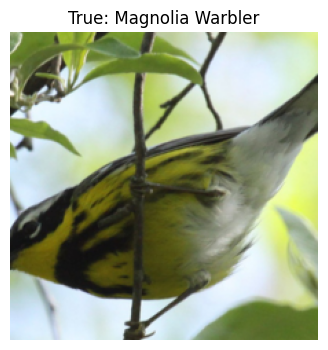

[OK] True: Magnolia Warbler
  Root   -> oscine
    because: has_primary_color::yellow | has_bill_shape::all-purpose | has_size::very_small_(3_-_5_in)
  Family -> warbler
    because: has_underparts_color::white | has_forehead_color::black | has_bill_color::black
  Genus  -> Magnolia Warbler
    because: has_underparts_color::yellow | has_crown_color::grey | has_belly_color::white



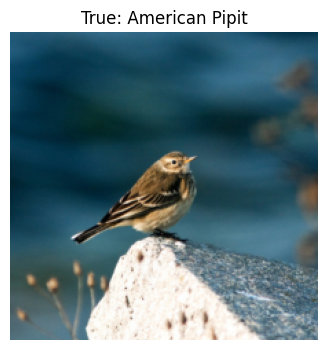

[XX] Predicted: Field Sparrow | True: American Pipit
  Root   -> New World sparrow
    because: has_bill_length::shorter_than_head | has_size::very_small_(3_-_5_in) | has_back_color::white
  Family -> field sparrow
    because: has_forehead_color::buff | has_crown_color::buff | has_underparts_color::buff
  Genus  -> Field Sparrow
    because: has_bill_shape::cone | has_wing_color::buff | has_upperparts_color::brown



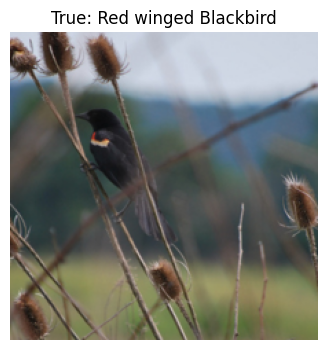

[XX] Predicted: Brewer Sparrow | True: Red winged Blackbird
  Root   -> passerine
    because: has_primary_color::brown | has_bill_length::shorter_than_head | has_bill_shape::cone
  Family -> sparrow
    because: has_bill_length::shorter_than_head | has_bill_shape::cone | has_belly_pattern::solid
  Genus  -> Brewer Sparrow
    because: has_forehead_color::black | has_crown_color::brown | has_breast_pattern::solid



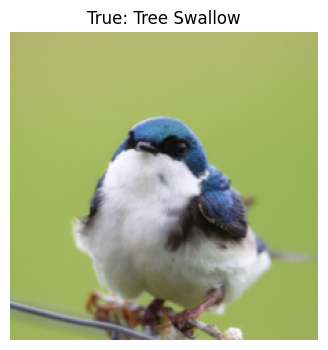

[OK] True: Tree Swallow
  Root   -> swallow
    because: has_crown_color::blue | has_belly_color::white | has_bill_length::shorter_than_head
  Family -> white-bellied swallow
    because: has_primary_color::white | has_shape::perching-like | has_upperparts_color::blue
  Genus  -> Tree Swallow
    because: has_wing_color::black



In [23]:
@torch.no_grad()
def explain_sample(model, image_tensor, concept_vector):
    """Generate a hierarchical explanation chain for a single image."""
    feats = model.features(image_tensor.unsqueeze(0).to(device))
    concepts_t = concept_vector.to(device)

    # Root -> family
    fam_logits, root_c = model.root_head(feats)
    pred_fid = int(fam_logits.argmax())
    root_c_vals = root_c[0].cpu().numpy()
    top_root = [root_concept_mask[i] for i in np.argsort(root_c_vals)[-5:][::-1]
                if root_c_vals[i] > 0.5]
    root_concept_names = [attrs_df.iloc[ci]['attr_name'] for ci in top_root[:3]]

    # Family -> genus
    g_log, fam_c = model.family_heads[str(pred_fid)](feats)
    gids_in_fam  = family_to_genera_map[pred_fid]
    pred_gid     = gids_in_fam[int(g_log.argmax())]
    fam_c_vals   = fam_c[0].cpu().numpy()
    top_fam = [family_concept_masks[pred_fid][i]
               for i in np.argsort(fam_c_vals)[-5:][::-1]
               if fam_c_vals[i] > 0.5]
    fam_concept_names = [attrs_df.iloc[ci]['attr_name'] for ci in top_fam[:3]]

    # Genus -> species
    s_log, gen_c = model.genus_heads[str(pred_gid)](feats)
    sp_in_gen    = genus_to_species_map[pred_gid]
    pred_sid     = sp_in_gen[int(s_log.argmax())]
    gen_c_vals   = gen_c[0].cpu().numpy()
    top_gen = [genus_concept_masks[pred_gid][i]
               for i in np.argsort(gen_c_vals)[-5:][::-1]
               if gen_c_vals[i] > 0.5]
    gen_concept_names = [attrs_df.iloc[ci]['attr_name'] for ci in top_gen[:3]]

    pred_sp_name = (classes_df[classes_df['class_id'] == pred_sid + 1]
                   ['class_name'].iloc[0].split('.', 1)[-1].replace('_', ' '))
    return {
        'family':        all_families[pred_fid],
        'root_concepts': root_concept_names,
        'genus':         all_genera[pred_gid],
        'fam_concepts':  fam_concept_names,
        'species':       pred_sp_name,
        'gen_concepts':  gen_concept_names,
    }

test_ds_noaug = CUBTaxonomyDataset(test_df, concept_matrix, CUB_DIR,
                                    species_to_genus, species_to_family, test_transform)
model.eval()

# Get all predictions and true labels from the 'final' dictionary
all_pred_sp = final['pred_sp']
all_true_sp = final['true_sp']

# Identify indices of correctly and incorrectly classified samples
correct_indices = [i for i, (pred, true) in enumerate(zip(all_pred_sp, all_true_sp)) if pred == true]
incorrect_indices = [i for i, (pred, true) in enumerate(zip(all_pred_sp, all_true_sp)) if pred != true]

# Randomly select 2 correct and 2 incorrect samples
np.random.seed(0) # Ensure reproducibility for sample selection
selected_correct_idxs = np.random.choice(correct_indices, 2, replace=False)
selected_incorrect_idxs = np.random.choice(incorrect_indices, 2, replace=False)

# Combine and shuffle for mixed display
display_sample_idxs = np.concatenate((selected_correct_idxs, selected_incorrect_idxs))
np.random.shuffle(display_sample_idxs)

print('Hierarchical Explanations  (root -> family -> genus -> species)')
print('=' * 70)

# Denormalize image function for display
def denormalize_image(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    tensor = tensor * std + mean  # Denormalize
    tensor = torch.clamp(tensor, 0, 1) # Clamp to [0,1]
    return tensor.permute(1, 2, 0).cpu().numpy()

for idx in display_sample_idxs:
    img, concepts, true_sp, _, _ = test_ds_noaug[int(idx)]
    true_name = (classes_df[classes_df['class_id'] == true_sp + 1]
                 ['class_name'].iloc[0].split('.', 1)[-1].replace('_', ' '))

    # Display the image
    plt.figure(figsize=(4, 4))
    plt.imshow(denormalize_image(img))
    plt.title(f'True: {true_name}')
    plt.axis('off')
    plt.show()

    expl = explain_sample(model, img, concepts)
    mark = 'OK' if expl['species'].lower() == true_name.lower() else 'XX'
    if mark == 'OK':
        print(f'[{mark}] True: {true_name}')
    else:
        print(f'[{mark}] Predicted: {expl['species']} | True: {true_name}')
    print(f'  Root   -> {expl["family"]}')
    if expl['root_concepts']:
        print(f'    because: {" | ".join(expl["root_concepts"])}')
    print(f'  Family -> {expl["genus"]}')
    if expl['fam_concepts']:
        print(f'    because: {" | ".join(expl["fam_concepts"])}');
    print(f'  Genus  -> {expl["species"]}')
    if expl['gen_concepts']:
        print(f'    because: {" | ".join(expl["gen_concepts"])}');
    print()

In [20]:
results = {
    'model':            'wordnet_cbm',
    'backbone':         'resnet50_finetuned',
    'taxonomy_source':  'wordnet',
    'n_families':       N_FAMILIES,
    'n_genera':         N_GENERA,
    'n_species':        N_CLASSES,
    'species_accuracy': final['species_acc'],
    'genus_accuracy':   final['genus_acc'],
    'family_accuracy':  final['family_acc'],
    'mean_tree_distance':      float(distances.mean()),
    'same_genus_mistake_rate': float(same_genus_rate),
    'same_family_mistake_rate':float(same_family_rate),
    'intervention': {
        'none':    acc_none,
        'family':  acc_family,
        'genus':   acc_genus,
        'species': acc_species,
        'all':     acc_all,
    }
}
out_path = os.path.join(SAVE_DIR, 'wordnet_cbm_results.json')
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved: {out_path}')
print(json.dumps(results, indent=2))


Saved: /content/processed/wordnet_cbm_results.json
{
  "model": "wordnet_cbm",
  "backbone": "resnet50_finetuned",
  "taxonomy_source": "wordnet",
  "n_families": 62,
  "n_genera": 109,
  "n_species": 200,
  "species_accuracy": 0.7813255091473938,
  "genus_accuracy": 0.8463928201587849,
  "family_accuracy": 0.8740075940628236,
  "mean_tree_distance": 0.9944770452191922,
  "same_genus_mistake_rate": 0.2975532754538279,
  "same_family_mistake_rate": 0.4246250986582478,
  "intervention": {
    "none": 0.7813255091473938,
    "family": 0.17017604418363824,
    "genus": 0.5015533310321022,
    "species": 0.48032447359337244,
    "all": 0.02554366586123576
  }
}


In [24]:
print('--- Hierarchical Taxonomy ---')
for fid, family_name in enumerate(all_families):
    print(f'\nFamily: {family_name} (ID: {fid})')
    gids_in_family = family_to_genera_map.get(fid, [])
    if not gids_in_family:
        print('  No genera in this family.')
        continue

    for gid in gids_in_family:
        genus_name = all_genera[gid]
        print(f'  Genus: {genus_name} (ID: {gid})')
        species_ids_in_genus = genus_to_species_map.get(gid, [])
        if not species_ids_in_genus:
            print('    No species in this genus.')
            continue

        # Map 0-indexed species ID back to 1-indexed class_id for lookup in classes_df
        species_names = []
        for sp_idx in species_ids_in_genus:
            class_id = sp_idx + 1 # Convert 0-indexed species to 1-indexed class_id
            species_name = classes_df[classes_df['class_id'] == class_id]['class_name'].iloc[0]
            species_names.append(species_name.split('.', 1)[-1].replace('_', ' '))
        print(f'    Species: {', '.join(species_names)}')


--- Hierarchical Taxonomy ---

Family: New World blackbird (ID: 0)
  Genus: cowbird (ID: 35)
    Species: Bronzed Cowbird, Shiny Cowbird
  Genus: rusty blackbird (ID: 83)
    Species: Rusty Blackbird

Family: New World flycatcher (ID: 1)
  Genus: kingbird (ID: 61)
    Species: Tropical Kingbird

Family: New World jay (ID: 2)
  Genus: blue jay (ID: 21)
    Species: Blue Jay

Family: New World oriole (ID: 3)
  Genus: New World blackbird (ID: 8)
    Species: Brewer Blackbird, Red winged Blackbird, Yellow headed Blackbird
  Genus: bobolink (ID: 22)
    Species: Bobolink
  Genus: meadowlark (ID: 68)
    Species: Horned Lark
  Genus: orchard oriole (ID: 74)
    Species: Orchard Oriole

Family: New World sparrow (ID: 4)
  Genus: chipping sparrow (ID: 31)
    Species: Chipping Sparrow
  Genus: field sparrow (ID: 40)
    Species: Field Sparrow
  Genus: song sparrow (ID: 86)
    Species: Song Sparrow
  Genus: vesper sparrow (ID: 94)
    Species: Vesper Sparrow

Family: New World warbler (ID: 5)
